## 1 图像的基础概念

##### 1. 什么是图像

##### 1.1 图像的本质
图像（Image）本质上是由很多像素（Pixel）组成的二维数据。

你可以把一张图像想象成一个“表格”：
* 表格中的每一个小格子 = 一个像素
* 每个像素里存着一个数值或一组数值
* 这些数值决定了这个位置显示什么颜色、亮度

所以，从计算机角度看：
* 图像不是“画”出来的
* 而是一堆数字按照行和列排列起来，再显示出来

✅ 这也是为什么在 CNN 中，图像可以作为模型输入：

因为它本质上就是一个张量（Tensor）/数组（Array）。

##### 1.2 像素（Pixel）是什么
像素是图像中最小的显示单位。

比如一张 256 × 256 的图像：
* 宽度有 256 个像素
* 高度有 256 个像素
* 一共就是 256 × 256 = 65536 个像素点

每个像素点记录的信息取决于图像类型：
* 二值图像：记录 0 或 1
* 灰度图像：记录一个亮度值
* 彩色图像：记录多个通道值，比如 RGB

##### 1.3 分辨率（Resolution）
分辨率就是图像的尺寸大小，通常写成：

`宽 × 高`

例如：
* 28 × 28：手写数字识别中常见
* 224 × 224：CNN经典输入尺寸
* 1920 × 1080：常见显示器分辨率

⚠️ 注意：
* 分辨率越高，图像包含的像素越多
* 像素越多，图像细节通常越丰富
* 但同时计算量也会更大

##### 1.4 图像为什么适合深度学习
因为图像天然可以表示成规则的数字网格：
* 它有固定的空间结构
* 相邻像素之间有关联
* 局部区域可以形成边缘、纹理、形状等特征

CNN 正是利用了这种“局部相关 + 空间结构”的特点来提取图像特征。🧠

#### 2. 图像的常见种类

##### 2.1 二值图像（Binary Image）
二值图像中，每个像素只有两种可能：
* 0：黑色
* 1 或 255：白色

也就是说，图像只有黑白两种颜色，没有灰色过渡。

例如：
```
[[0, 0, 255],
 [255, 0, 255],
 [0, 255, 0]]
```
特点：
* 数据最简单
* 存储空间最小
* 常用于文字识别、掩膜（mask）、轮廓处理等

📌 在很多图像分割任务中，标签图常常就是二值图。

##### 2.2 灰度图像（Grayscale Image）
灰度图像中，每个像素表示亮度强弱。

常见范围：
* 0 表示黑色
* 255 表示白色
* 中间值表示不同程度的灰色

例如：
```
[[  0,  50, 100],
 [150, 200, 255]]
```
特点：
* 只有一个通道
* 比彩色图简单
* 常用于医学图像、手写数字识别、边缘检测等

📌 例如 MNIST 手写数字图像，本质上就是灰度图像。

##### 2.3 索引图像（Indexed Image）
索引图像中的像素值本身不是直接表示颜色，而是表示“颜色表中的索引编号”。

也就是说：
* 图像数组中保存的是编号
* 真正显示什么颜色，要去查一个“调色板（Color Map / Palette）”

例如：

图像数据：
```
[[0, 1, 2],
 [2, 1, 0]]
```
颜色表（Map）：
* 0 → 黑色
* 1 → 红色
* 2 → 蓝色

那么显示出来的图像才有对应颜色。

特点：
* 节省存储空间
* 常用于早期图像格式、GIF等
* 在深度学习中不如灰度图和彩色图常见

📌 可以把它理解为：

`“像素里存的不是颜色本身，而是颜色编号”。`

##### 2.4 真彩色 RGB 图像（True Color RGB Image）
RGB 图像中，每个像素由三个通道组成：
* R = Red 红色
* G = Green 绿色
* B = Blue 蓝色

每个通道通常范围是：

`0 ~ 255`

例如某个像素：

`[255, 0, 0]`

表示纯红色。

再比如：
* [0, 255, 0] → 纯绿色
* [0, 0, 255] → 纯蓝色
* [255, 255, 255] → 白色
* [0, 0, 0] → 黑色

特点：
* 最常见的彩色图像格式
* 一张 RGB 图像本质上是三个二维矩阵叠加
* 在计算机视觉任务中最常见

📌 对于 CNN 来说，RGB 图像通常表示为：

`高度 × 宽度 × 3`

或者在 PyTorch 中常见为：

`3 × 高度 × 宽度`

#### 3. 图像的shape, chanel, dtype, 大小

##### 3.1 从数学角度看图像
图像本质上就是矩阵或多维数组。

不同图像类型对应不同的数据表示：
* 二值图像 → 二维矩阵
* 灰度图像 → 二维矩阵
* RGB 图像 → 三维数组

##### 3.2 图像 shape 的含义
这是后面 CNN 最重要的基础之一。⭐

图像常见 shape：

**（1）灰度图**

`(H, W)`

例如：

`(28, 28)`

表示：
* H = Height，高度
* W = Width，宽度

**（2）彩色图（NumPy / matplotlib / OpenCV中常见）**

`(H, W, C)`

例如：

`(224, 224, 3)`

表示：
* 高度 224
* 宽度 224
* 通道数 3

这里 C = Channels

**（3）PyTorch 中常见单张图像格式**

`(C, H, W)`

例如：

`(3, 224, 224)`

这是因为 PyTorch 通常把通道放前面。

**（4）批量图像在深度学习中的格式**

如果一次输入多张图像，还会多一个 batch 维度：

在 PyTorch 中通常是：

`(N, C, H, W)`

例如：

`(32, 3, 224, 224)`

表示：
* 一次输入 32 张图片
* 每张图片 3 个通道
* 高 224，宽 224

📌 这里：
* N = batch size
* C = channel
* H = height
* W = width

这个格式后面学 CNN 时必须非常熟悉。

##### 3.3 通道（Channel）
通道可以理解为：

`同一张图像中，不同类型的信息层。`

例如 RGB 图像：
* 红色信息是一层
* 绿色信息是一层
* 蓝色信息是一层

所以 RGB 图像有 3 个通道。

而灰度图只有 1 个通道，因为它只记录亮度，没有颜色拆分。

📌 可以把彩色图理解成三张“透明薄膜”叠在一起：
* 第一层记录红色强弱
* 第二层记录绿色强弱
* 第三层记录蓝色强弱

最后叠加成完整彩色图像。🎨

所以图像不能简单当作普通表格特征处理，否则会丢失空间关系。

CNN 的核心作用，就是在保留空间结构的前提下提取特征。

##### 3.4 数据类型（dtype）
图像不仅有 shape，还有数据类型 dtype。

常见类型：
* uint8：最常见，范围 0~255
* float32：深度学习中很常见
* bool：二值图有时会用

例如：

`img.dtype`

可能输出：

`dtype('uint8')`

这表示每个像素是 8 位无符号整数。

##### 3.5 数据大小归一化
原始图像像素通常是：

`0 ~ 255`

但神经网络训练时，常把它缩放到：

`0 ~ 1`

或者进一步标准化成均值附近分布。

例如：

`img = img / 255.0`

这样做的原因：
* 数值更稳定
* 更利于梯度下降
* 训练更容易收敛

📌 所以：
* 图像原始存储时常是 uint8
* 输入神经网络前常转为 float32
* 再做归一化/标准化

#### 4. 图像坐标与读取方式

##### 4.1 图像坐标怎么理解
图像本质上是二维数组，所以读取一个像素时通常使用：

`img[row, col]`

也就是：

`img[y, x]`

注意这里和数学坐标系不完全一样：
* 图像左上角通常是原点 (0, 0)
* 向右是列增加
* 向下是行增加

📌 所以图像坐标系中：
* 第一维：行，高度方向
* 第二维：列，宽度方向

##### 4.2 灰度图像读取像素
对于灰度图：

`pixel = img[10, 20]`

表示第 10 行、第 20 列的亮度值。

返回的通常是一个数字，比如：

`128`

##### 4.3 RGB 图像读取像素
对于 RGB 图：

`pixel = img[10, 20]`

返回的是三个值，例如：

`[123, 200, 45]`

含义是：
* R = 123
* G = 200
* B = 45

如果想单独取某个通道：
```
r = img[10, 20, 0]
g = img[10, 20, 1]
b = img[10, 20, 2]
```

#### 5. 使用 matplotlib 加载和显示图像
matplotlib 是 Python 中最常用的可视化库之一。

在学习 CNN 前，我们需要先学会：
* 加载图像
* 查看图像 shape
* 显示图像
* 显示灰度图和彩色图
* 简单观察图像数据

这对后面做数据预处理很重要。📷

##### 5.1 常用导入方式
```
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
```
其中：
* plt：负责显示图像
* mpimg：负责读取图像
* numpy：辅助查看数组信息

##### 5.2 加载图像
使用 `mpimg.imread()`

`img = mpimg.imread("cat.png")`

加载后，img 通常是一个 NumPy 数组。

可以查看：
```
print(type(img))
print(img.shape)
print(img.dtype)
```
例如输出：
```
<class 'numpy.ndarray'>
(400, 600, 3)
uint8
```
表示：
* 是 NumPy 数组
* 高 400，宽 600，3通道
* 数据类型是 uint8

##### 5.3 显示图像
使用 `plt.imshow()`

**（1）显示彩色图像**
```
plt.imshow(img)
plt.show()
```

**（2）显示灰度图像**
如果是灰度图，最好加上：
```
plt.imshow(img, cmap="gray")
plt.show()
```
这里：
* cmap="gray" 表示使用灰度色图显示
* 否则 matplotlib 可能默认用伪彩色显示，不直观。


##### 5.4 完整示例

Image shape: (208, 176)
Image data type: uint8
Pixel value range: 0 to 254


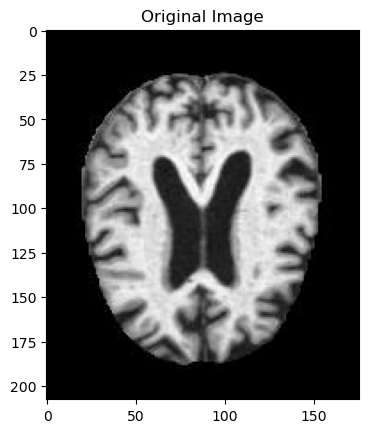

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image = mpimg.imread('/home/zhang/Documents/Programming/DataAnalysis_AI-Learning/3.DL_Learning/4. CNN/data/26 (19).jpg')

print("Image shape:", image.shape)
print("Image data type:", image.dtype)
print("Pixel value range:", np.min(image), "to", np.max(image))

ax, fig = plt.subplots()
fig.imshow(image, cmap='gray')
fig.set_title('Original Image')
plt.show()


##### 5.5 查看单个像素值

In [5]:
print("Pixel value:", image[0,0])

Pixel value: 0


##### 5.6 读取后为什么有时数值是 0~1
有些图像读取方式，尤其某些 PNG 文件，读取后可能得到浮点数：

`0.0 ~ 1.0`

而不是：

`0 ~ 255`

这取决于库和图像格式。

所以读取图像后，最好先检查：
```
print(img.dtype)
print(img.min(), img.max())
```

#### 6. 图像表示与 CNN 的直接联系

##### 6.1 CNN 为什么关心 shape
因为卷积层接收输入时，必须知道：
* 通道数是多少
* 图像高和宽是多少
* 一次输入多少张图

例如 PyTorch 卷积层希望输入：

`(N, C, H, W)`

如果你的图像 shape 不对，就会报错。⚠️

##### 6.2 为什么灰度图和 RGB 图处理方式不同
因为输入通道数不同：
* 灰度图：1 通道
* RGB 图：3 通道

比如第一层卷积核的输入深度要与通道数匹配。

所以在定义 CNN 时，常见写法有：
* 灰度图输入：in_channels=1
* RGB 图输入：in_channels=3